In [3]:
import pandas as pd

df = pd.read_csv('/content/Airline Dataset.csv')

display(df.head())

,Passenger ID,First Name,Last Name,Gender,Age,Nationality,Airport Name,Airport Country Code,Country Name,Airport Continent,Continents,Departure Date,Arrival Airport,Pilot Name,Flight Status
0,10856,Edithe,Leggis,Female,62,Japan,Coldfoot Airport,US,United States,NAM,North America,6/28/2022,CXF,Edithe Leggis,On Time
1,43872,Elwood,Catt,Male,62,Nicaragua,Kugluktuk Airport,CA,Canada,NAM,North America,12/26/2022,YCO,Elwood Catt,On Time
2,42633,Darby,Felgate,Male,67,Russia,Grenoble-Isère Airport,FR,France,EU,Europe,1/18/2022,GNB,Darby Felgate,On Time
3,78493,Dominica,Pyle,Female,71,China,Ottawa / Gatineau Airport,CA,Canada,NAM,North America,9/16/2022,YND,Dominica Pyle,Delayed
4,82072,Bay,Pencost,Male,21,China,Gillespie Field,US,United States,NAM,North America,2/25/2022,SEE,Bay Pencost,On Time


In [4]:
Y = df['Flight Status']

In [12]:
X = df[['Age',
        'Gender',
        'Nationality',
        'Airport Country Code',
        'Airport Continent']]

Y = df['Flight Status']

In [13]:
# Check for missing values in X
missing_values_X = X.isnull().sum()
display(missing_values_X)

,0
Age,0
Gender,0
Nationality,0
Airport Country Code,0
Airport Continent,0


In [5]:
flight_status_counts = Y.value_counts()
display(flight_status_counts)

,count
Flight Status,
Cancelled,32942
On Time,32846
Delayed,32831


In [6]:
flight_status_age_distribution = df.groupby(['Age', 'Flight Status']).size().unstack(fill_value=0)
display(flight_status_age_distribution.head())

Flight Status,Cancelled,Delayed,On Time
Age,,,
1,348,393,334
2,382,346,330
3,387,367,341
4,359,379,372
5,354,359,369


<Figure size 1500x700 with 0 Axes>

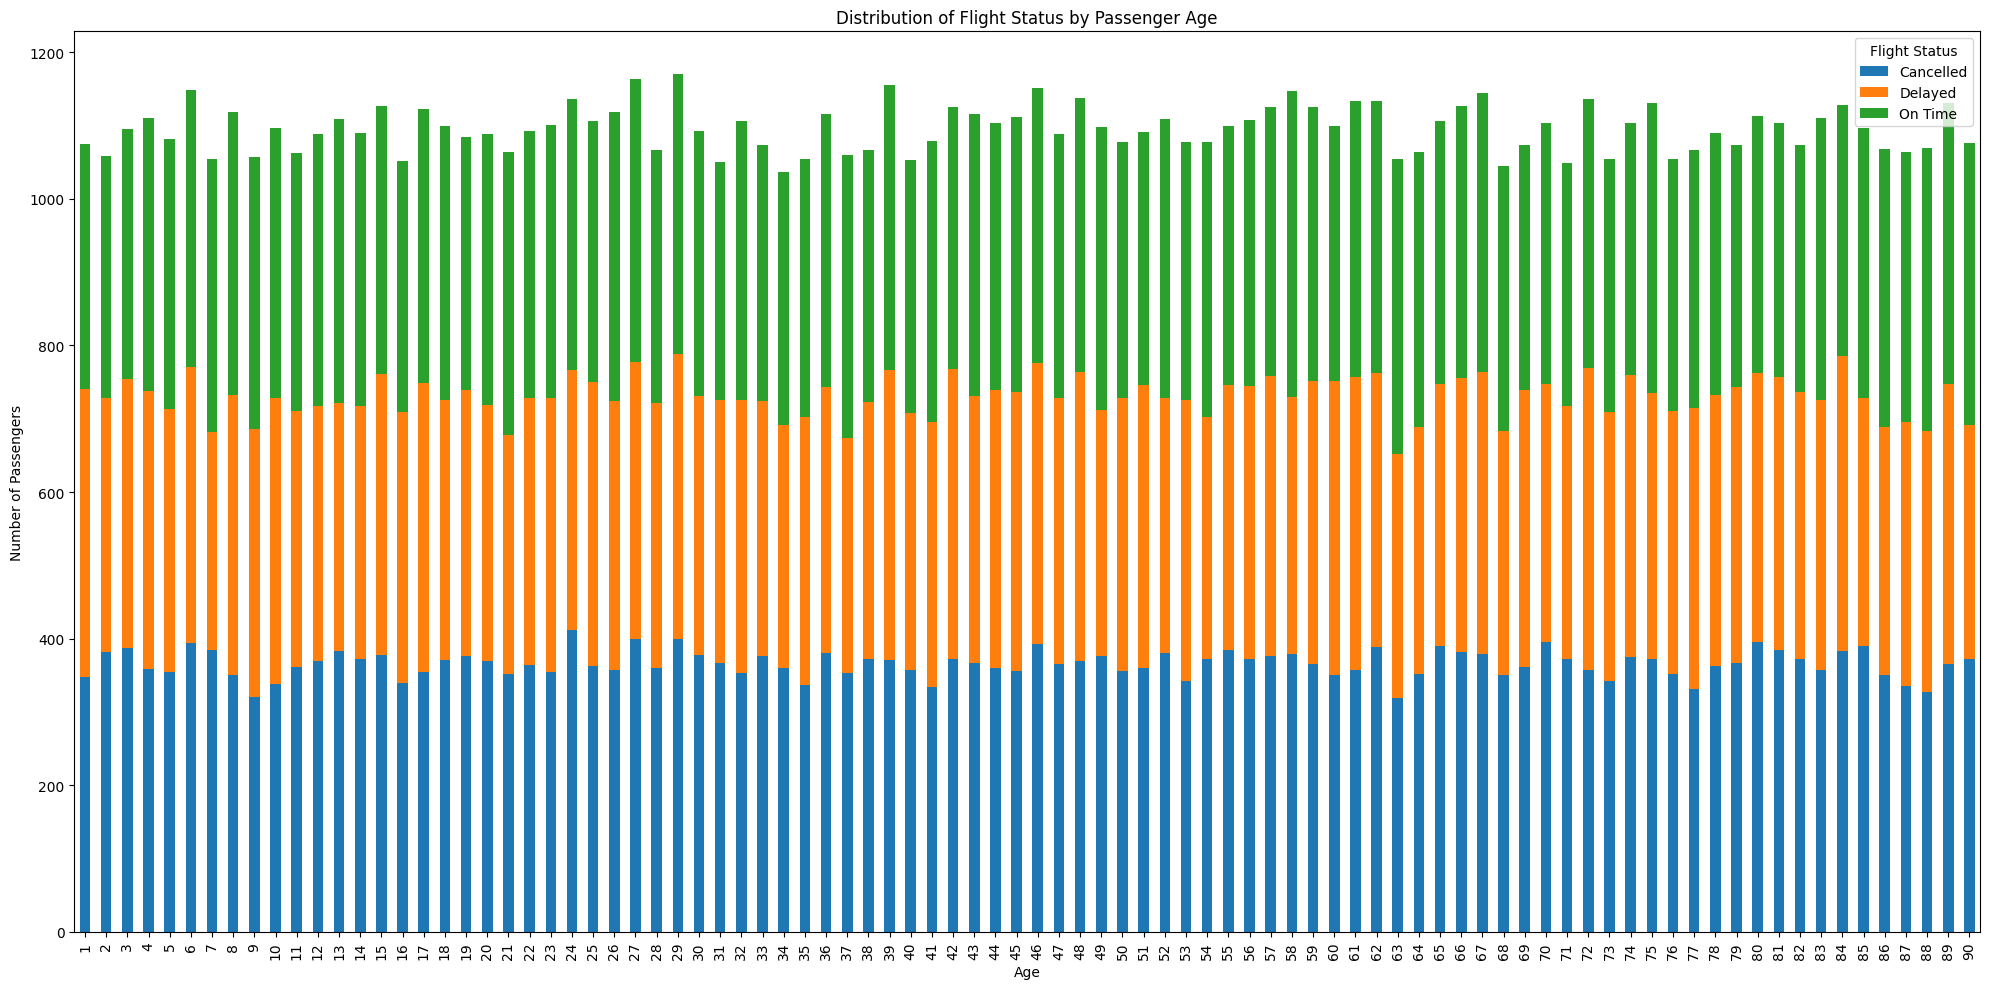

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 7))
flight_status_age_distribution.plot(kind='bar', stacked=True, figsize=(20, 10))
plt.title('Distribution of Flight Status by Passenger Age')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.xticks(rotation=90)
plt.legend(title='Flight Status')
plt.tight_layout()
plt.show()

In [8]:
# Calculate the number of delayed flights per airport
delayed_flights_per_airport = df[df['Flight Status'] == 'Delayed'].groupby('Airport Name').size().reset_index(name='Delayed Count')

# Calculate the total number of flights per airport
total_flights_per_airport = df.groupby('Airport Name').size().reset_index(name='Total Count')

# Merge the two dataframes
airport_delay_stats = pd.merge(total_flights_per_airport, delayed_flights_per_airport, on='Airport Name', how='left')
airport_delay_stats['Delayed Count'] = airport_delay_stats['Delayed Count'].fillna(0)

# Calculate the delay rate
airport_delay_stats['Delay Rate'] = (airport_delay_stats['Delayed Count'] / airport_delay_stats['Total Count']) * 100

# Sort by Delay Rate in descending order and display the top 10
top_10_delayed_airports = airport_delay_stats.sort_values(by='Delay Rate', ascending=False).head(10)
display(top_10_delayed_airports)

,Airport Name,Total Count,Delayed Count,Delay Rate
3626,Jefferson Municipal Airport,4,4.0,100.0
732,Batna Airport,3,3.0,100.0
7601,St Clair County Airport,9,9.0,100.0
3898,Kasba Lake Airport,3,3.0,100.0
3700,Jorge Wilsterman International Airport,3,3.0,100.0
6841,Robin Hood Doncaster Sheffield Airport,3,3.0,100.0
1249,Caia Airport,5,5.0,100.0
2331,El Palomar Airport,6,6.0,100.0
1369,Caquetania Airport,7,7.0,100.0
256,Amasya Merzifon Airport,5,5.0,100.0


/tmp/ipykernel_639/1717651775.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Delay Rate', y='Airport Name', data=top_10_delayed_airports, palette='viridis')


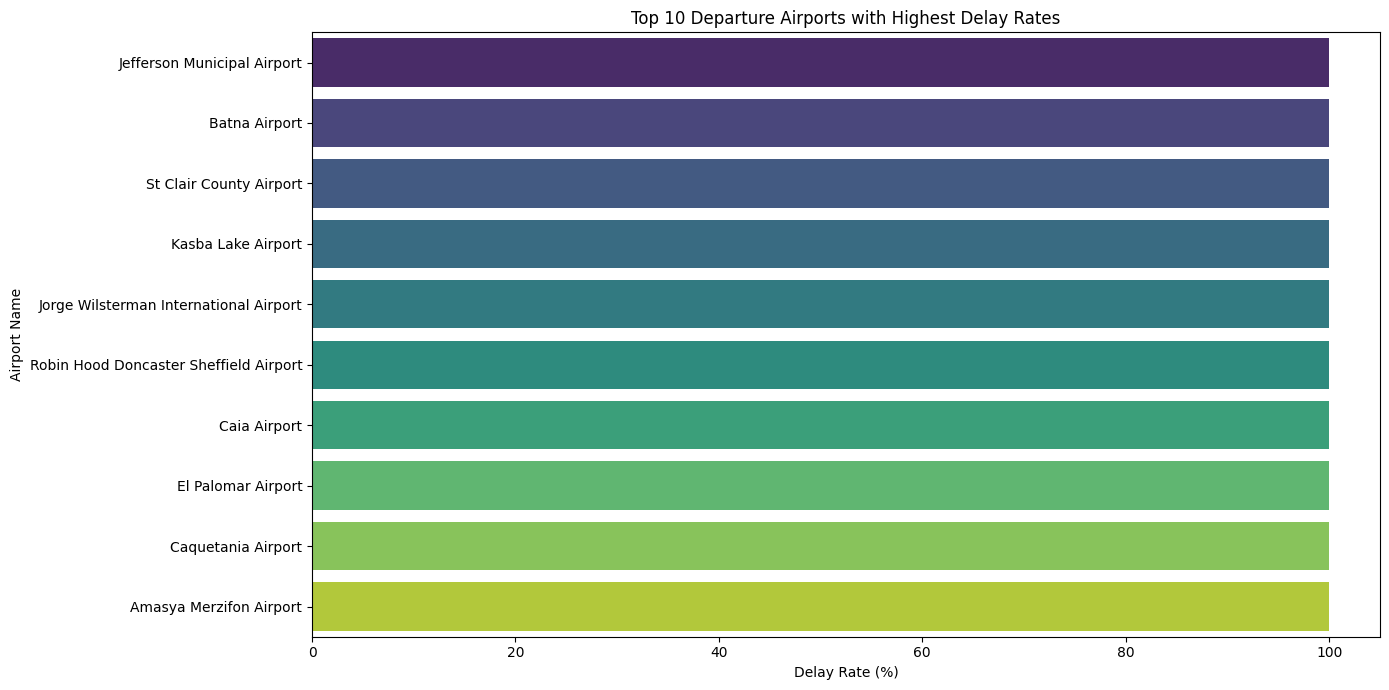

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))
sns.barplot(x='Delay Rate', y='Airport Name', data=top_10_delayed_airports, palette='viridis')
plt.title('Top 10 Departure Airports with Highest Delay Rates')
plt.xlabel('Delay Rate (%)')
plt.ylabel('Airport Name')
plt.tight_layout()
plt.show()

In [10]:
# Calculate the number of on-time flights per airport
on_time_flights_per_airport = df[df['Flight Status'] == 'On Time'].groupby('Airport Name').size().reset_index(name='On Time Count')

# Merge with total flights to get on-time rate
airport_on_time_stats = pd.merge(total_flights_per_airport, on_time_flights_per_airport, on='Airport Name', how='left')
airport_on_time_stats['On Time Count'] = airport_on_time_stats['On Time Count'].fillna(0)

# Calculate the On Time Rate
airport_on_time_stats['On Time Rate'] = (airport_on_time_stats['On Time Count'] / airport_on_time_stats['Total Count']) * 100

# Display the top airports by total count with their on-time rates to get a sense
display(airport_on_time_stats.sort_values(by='Total Count', ascending=False).head())

,Airport Name,Total Count,On Time Count,On Time Rate
7079,San Pedro Airport,43,17.0,39.534884
7131,Santa Maria Airport,38,9.0,23.684211
1221,Böblingen Flugfeld,36,13.0,36.111111
7112,Santa Ana Airport,35,15.0,42.857143
7050,San Fernando Airport,31,11.0,35.483871


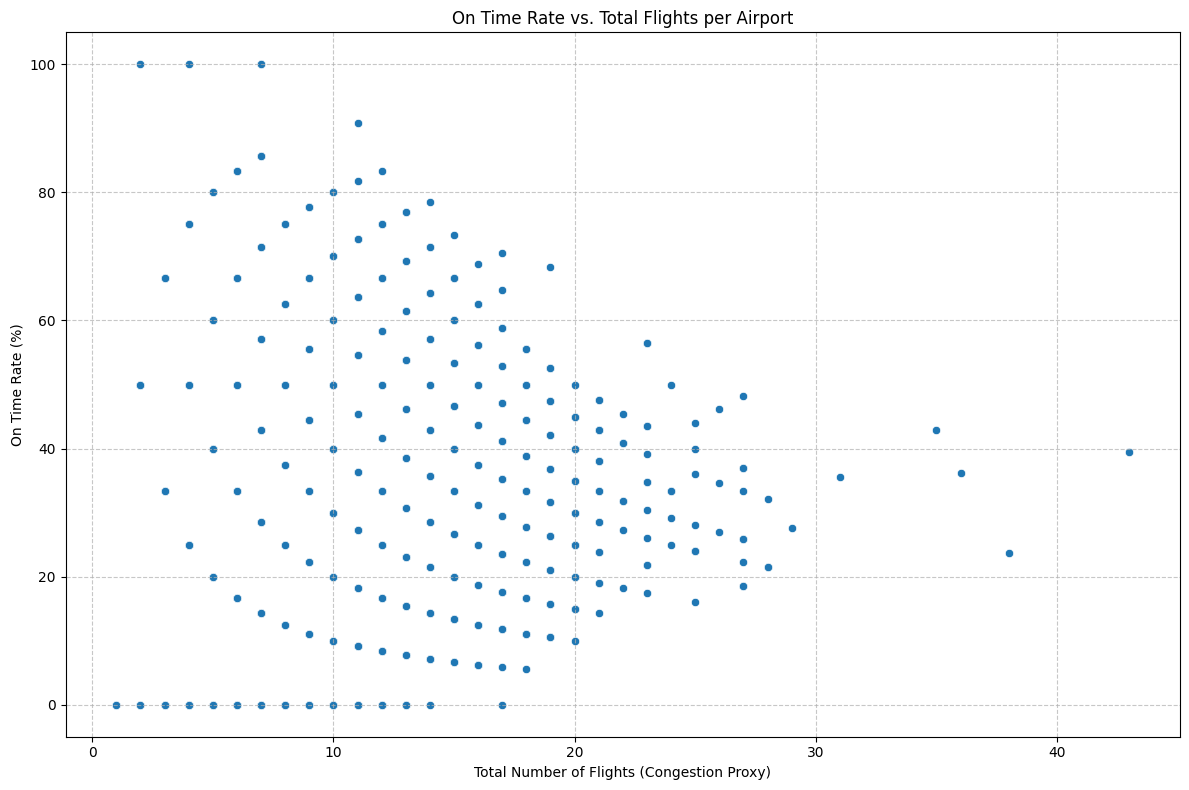

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.scatterplot(x='Total Count', y='On Time Rate', data=airport_on_time_stats)
plt.title('On Time Rate vs. Total Flights per Airport')
plt.xlabel('Total Number of Flights (Congestion Proxy)')
plt.ylabel('On Time Rate (%)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()